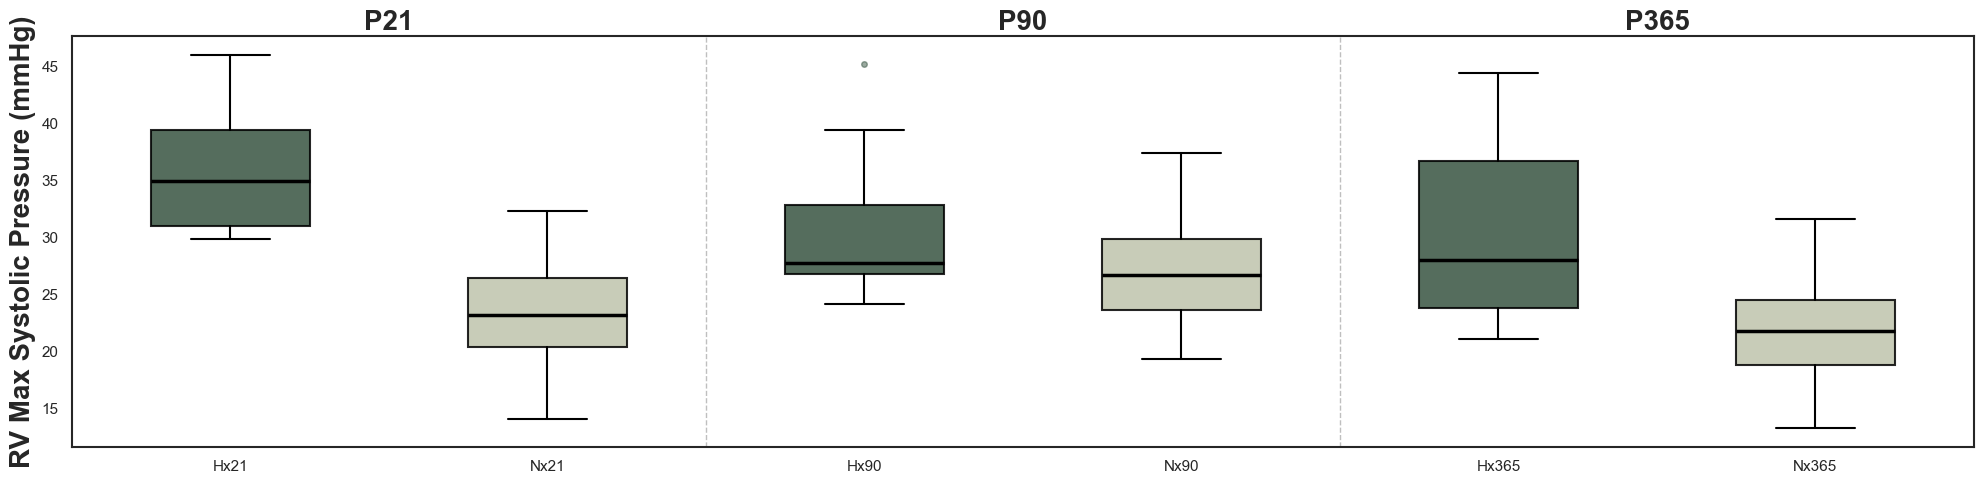

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", palette=None)

color_hx = "#375441"
color_nx = "#bfc4ac"

data = {
    'Hx21':  [38.15, 30.65, 31.22312635, 37.75631462, 29.89213995, 40.65, 46.01, 39.28, 31.09020491, 32.07855451, 30.33458, 39.85837719],
    'Nx21':  [32.35, 18.88, 21.91507469, 14.08, 25.02987035, 23.19667095, 27.80112346],
    'Hx90':  [45.19497105, 26.78443299, 27.78, 39.45, 27.79071632, 29.21421133, 24.14589993, 26.87, 34.08, 25.1622031],
    'Nx90':  [29.0313998, 29.90, 26.68, 21.10, 37.36353141, 31.47607499, 23.61092576, 19.32, 24.96943773],
    'Hx365': [36.6, 27.0, 41.9, 36.9, 23.8, 25.6, 44.4, 33.2, 25.0, 30.8, 28.0, 22.5, 39.9, 36.7, 22.7, 21.6, 21.1],
    'Nx365': [13.3, 21.7, 25.9, 31.6, 21.9, 20.8, 27.4, 20.4, 18.3, 26.3, 18.9, 24.1, 22.6, 22.3, 18.7, 18.2],
}

groups = list(data.keys())
colors = [color_hx, color_nx, color_hx, color_nx, color_hx, color_nx]

fig, ax = plt.subplots(figsize=(20, 5))

bp = ax.boxplot(
    [data[g] for g in groups],
    patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2.5, color='black'),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', alpha=0.5, markersize=4),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels(groups)
ax.set_ylabel('RV Max Systolic Pressure (mmHg)', fontsize=20, fontweight='bold')

# Age dividers
for x in [2.5, 4.5]:
    ax.axvline(x, color='gray', linewidth=1, linestyle='--', alpha=0.5)

# Age labels
for x, label in [(1.5, 'P21'), (3.5, 'P90'), (5.5, 'P365')]:
    ax.text(x, ax.get_ylim()[1], label, ha='center', va='bottom',
            fontsize=20, fontweight='bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5)

plt.tight_layout()
plt.show()

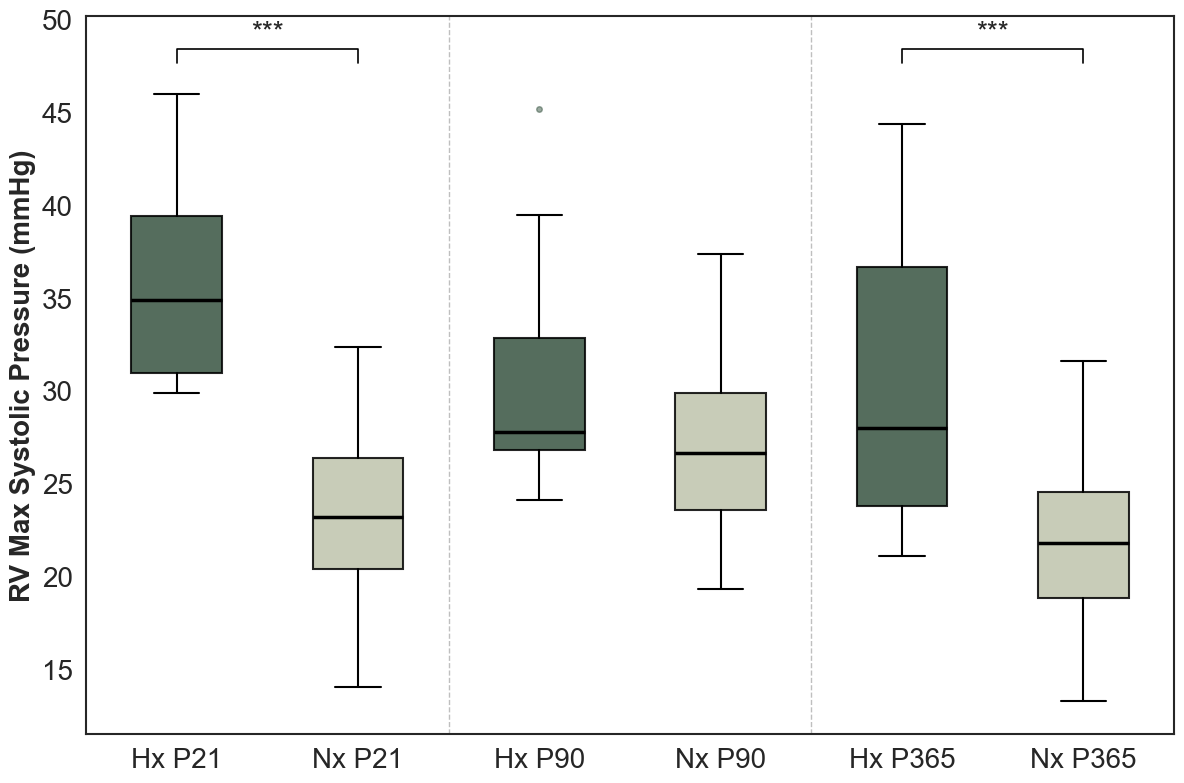

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

sns.set_theme(style="white", palette=None)

color_hx = "#375441"
color_nx = "#bfc4ac"

data = {
    'Hx P21':  [38.15, 30.65, 31.22312635, 37.75631462, 29.89213995, 40.65, 46.01, 39.28, 31.09020491, 32.07855451, 30.33458, 39.85837719],
    'Nx P21':  [32.35, 18.88, 21.91507469, 14.08, 25.02987035, 23.19667095, 27.80112346],
    'Hx P90':  [45.19497105, 26.78443299, 27.78, 39.45, 27.79071632, 29.21421133, 24.14589993, 26.87, 34.08, 25.1622031],
    'Nx P90':  [29.0313998, 29.90, 26.68, 21.10, 37.36353141, 31.47607499, 23.61092576, 19.32, 24.96943773],
    'Hx P365': [36.6, 27.0, 41.9, 36.9, 23.8, 25.6, 44.4, 33.2, 25.0, 30.8, 28.0, 22.5, 39.9, 36.7, 22.7, 21.6, 21.1],
    'Nx P365': [13.3, 21.7, 25.9, 31.6, 21.9, 20.8, 27.4, 20.4, 18.3, 26.3, 18.9, 24.1, 22.6, 22.3, 18.7, 18.2],
}

groups = list(data.keys())
colors = [color_hx, color_nx, color_hx, color_nx, color_hx, color_nx]
pairs = [(1, 2), (3, 4), (5, 6)]  # 1-indexed box positions for (Hx, Nx) at each age

def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return None

fig, ax = plt.subplots(figsize=(12, 8))

bp = ax.boxplot(
    [data[g] for g in groups],
    patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2.5, color='black'),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', alpha=0.5, markersize=4),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Age dividers and labels
for x in [2.5, 4.5]:
    ax.axvline(x, color='gray', linewidth=1, linestyle='--', alpha=0.5)

ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels(groups)
ax.set_ylabel('RV Max Systolic Pressure (mmHg)', fontsize=20, fontweight='bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5,labelsize=20)

# Significance brackets
y_max = max(max(v) for v in data.values())
y_range = y_max - min(min(v) for v in data.values())
bracket_base = y_max + y_range * 0.05
step = y_range * 0.08

for i, (hx_key, nx_key) in enumerate([('Hx P21','Nx P21'), ('Hx P90','Nx P90'), ('Hx P365','Nx P365')]):
    _, p = stats.ttest_ind(data[hx_key], data[nx_key], equal_var=False)
    label = significance_label(p)
    if label:
        x1, x2 = pairs[i]
        y = bracket_base + i * 0  # all at same height since non-overlapping
        ax.plot([x1, x1, x2, x2], [y, y + step*0.3, y + step*0.3, y],
                color='black', linewidth=1.2)
        ax.text((x1 + x2) / 2, y + step*0.35, label,
                ha='center', va='bottom', fontsize=20)


plt.tight_layout()
plt.show()